### Speech-Text Cross-Modal Alignment Visualization

This script demonstrates the alignment between speech representations (MFCCs, Mel spectrograms) and text tokens extracted from transcribed speech. It visualizes how linguistic units map to acoustic features in time, providing insight into speech-language relationships.

Key Libraries Used:

    whisper: Speech-to-text transcription

    transformers: BERT tokenizer for subword tokenization

    librosa: Audio feature extraction

    matplotlib: Alignment visualization

Code Logic and Flow

The pipeline:

    Loads and transcribes audio

    Extracts MFCCs and Mel spectrogram features

    Tokenizes transcription using BERT

    Aligns tokens to audio frames uniformly

    Visualizes tokens overlaid on acoustic features


Visual FlowChart:    

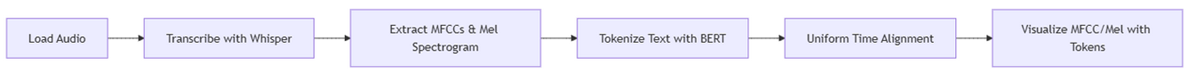

 
Step-by-Step Code Breakdown

1. Audio Loading

    Reads WAV file at 16kHz sample rate

    Calculates audio duration dynamically

    Uses librosa for format-agnostic loading

2. Speech Transcription

    Employs Whisper-base model

    Handles multilingual input automatically

    Returns raw text transcription

3. Feature Extraction

    MFCCs:

        13 coefficients capturing spectral envelope

        Emphasizes perceptually relevant features

    Mel Spectrogram:

        80-band frequency representation

        Log-scaled (dB) for dynamic range compression

4. Text Tokenization

    Uses BERT uncased tokenizer

    Converts text to subword tokens (e.g., "language"  ["lang", "##uage"])

    Generates token IDs for numerical representation

5. Uniform Alignment

    Distributes tokens evenly across audio duration

    Calculates time points: token_position  (duration / token_count)

    Maps to nearest MFCC frame index

    Simple heuristic for demonstration purposes

6. Visualization

    MFCC Plot:

        13 coefficient dimensions over time

        Tokens rotated 45 at aligned time points

    Mel Spectrogram:

        80 Mel bands showing energy distribution

        Token annotations at same temporal positions

    High-resolution (120dpi) output saved as PNG

Connecting to Lecture Concepts

This implementation demonstrates:

    Acoustic-Phonetic Mapping: How speech features correlate with linguistic units

    Temporal Alignment Challenge: Uniform distribution vs. actual phoneme durations

    Subword Tokenization: Balance between vocabulary size and sequence length

    Feature Hierarchies:

        MFCCs: Compact phonetic representation

        Mel: Rich spectral detail

    Cross-Modal Gap: Mismatch between continuous speech and discrete tokens

    Visual Diagnostics: Identifying alignment inaccuracies

    Whisper Integration: End-to-ASR for realistic transcription

    Real-World Limitations:

        Coarticulation effects ignored

        Variable speaking rates not modeled

        Phoneme-boundary ambiguity

    Research Foundation: Basis for attention mechanisms in speech-text models

    SpeechLM Relevance: Prepares for token-level processing in module 3.2

    Perceptual Correlation: Vowels show higher Mel energy, consonants affect MFCCs


Whisper ASR Transcript:  Hi, this audio is for use in the coding example for the speech alarm course. Let's see how this works.
Text Tokens: ['hi', ',', 'this', 'audio', 'is', 'for', 'use', 'in', 'the', 'coding', 'example', 'for', 'the', 'speech', 'alarm', 'course', '.', 'let', "'", 's', 'see', 'how', 'this', 'works', '.']
Token IDs: [7632, 1010, 2023, 5746, 2003, 2005, 2224, 1999, 1996, 16861, 2742, 2005, 1996, 4613, 8598, 2607, 1012, 2292, 1005, 1055, 2156, 2129, 2023, 2573, 1012]

Cross-Modal Alignment:
Tokens per Frame: 0.06
Token: hi, Time: 0.27s, Frame: 0
Token: ,, Time: 0.82s, Frame: 17
Token: this, Time: 1.36s, Frame: 34
Token: audio, Time: 1.91s, Frame: 51
Token: is, Time: 2.45s, Frame: 68
Token: for, Time: 2.99s, Frame: 85
Token: use, Time: 3.54s, Frame: 102
Token: in, Time: 4.08s, Frame: 119
Token: the, Time: 4.63s, Frame: 136
Token: coding, Time: 5.17s, Frame: 153
Token: example, Time: 5.72s, Frame: 170
Token: for, Time: 6.26s, Frame: 187
Token: the, Time: 6.80s, Frame: 204

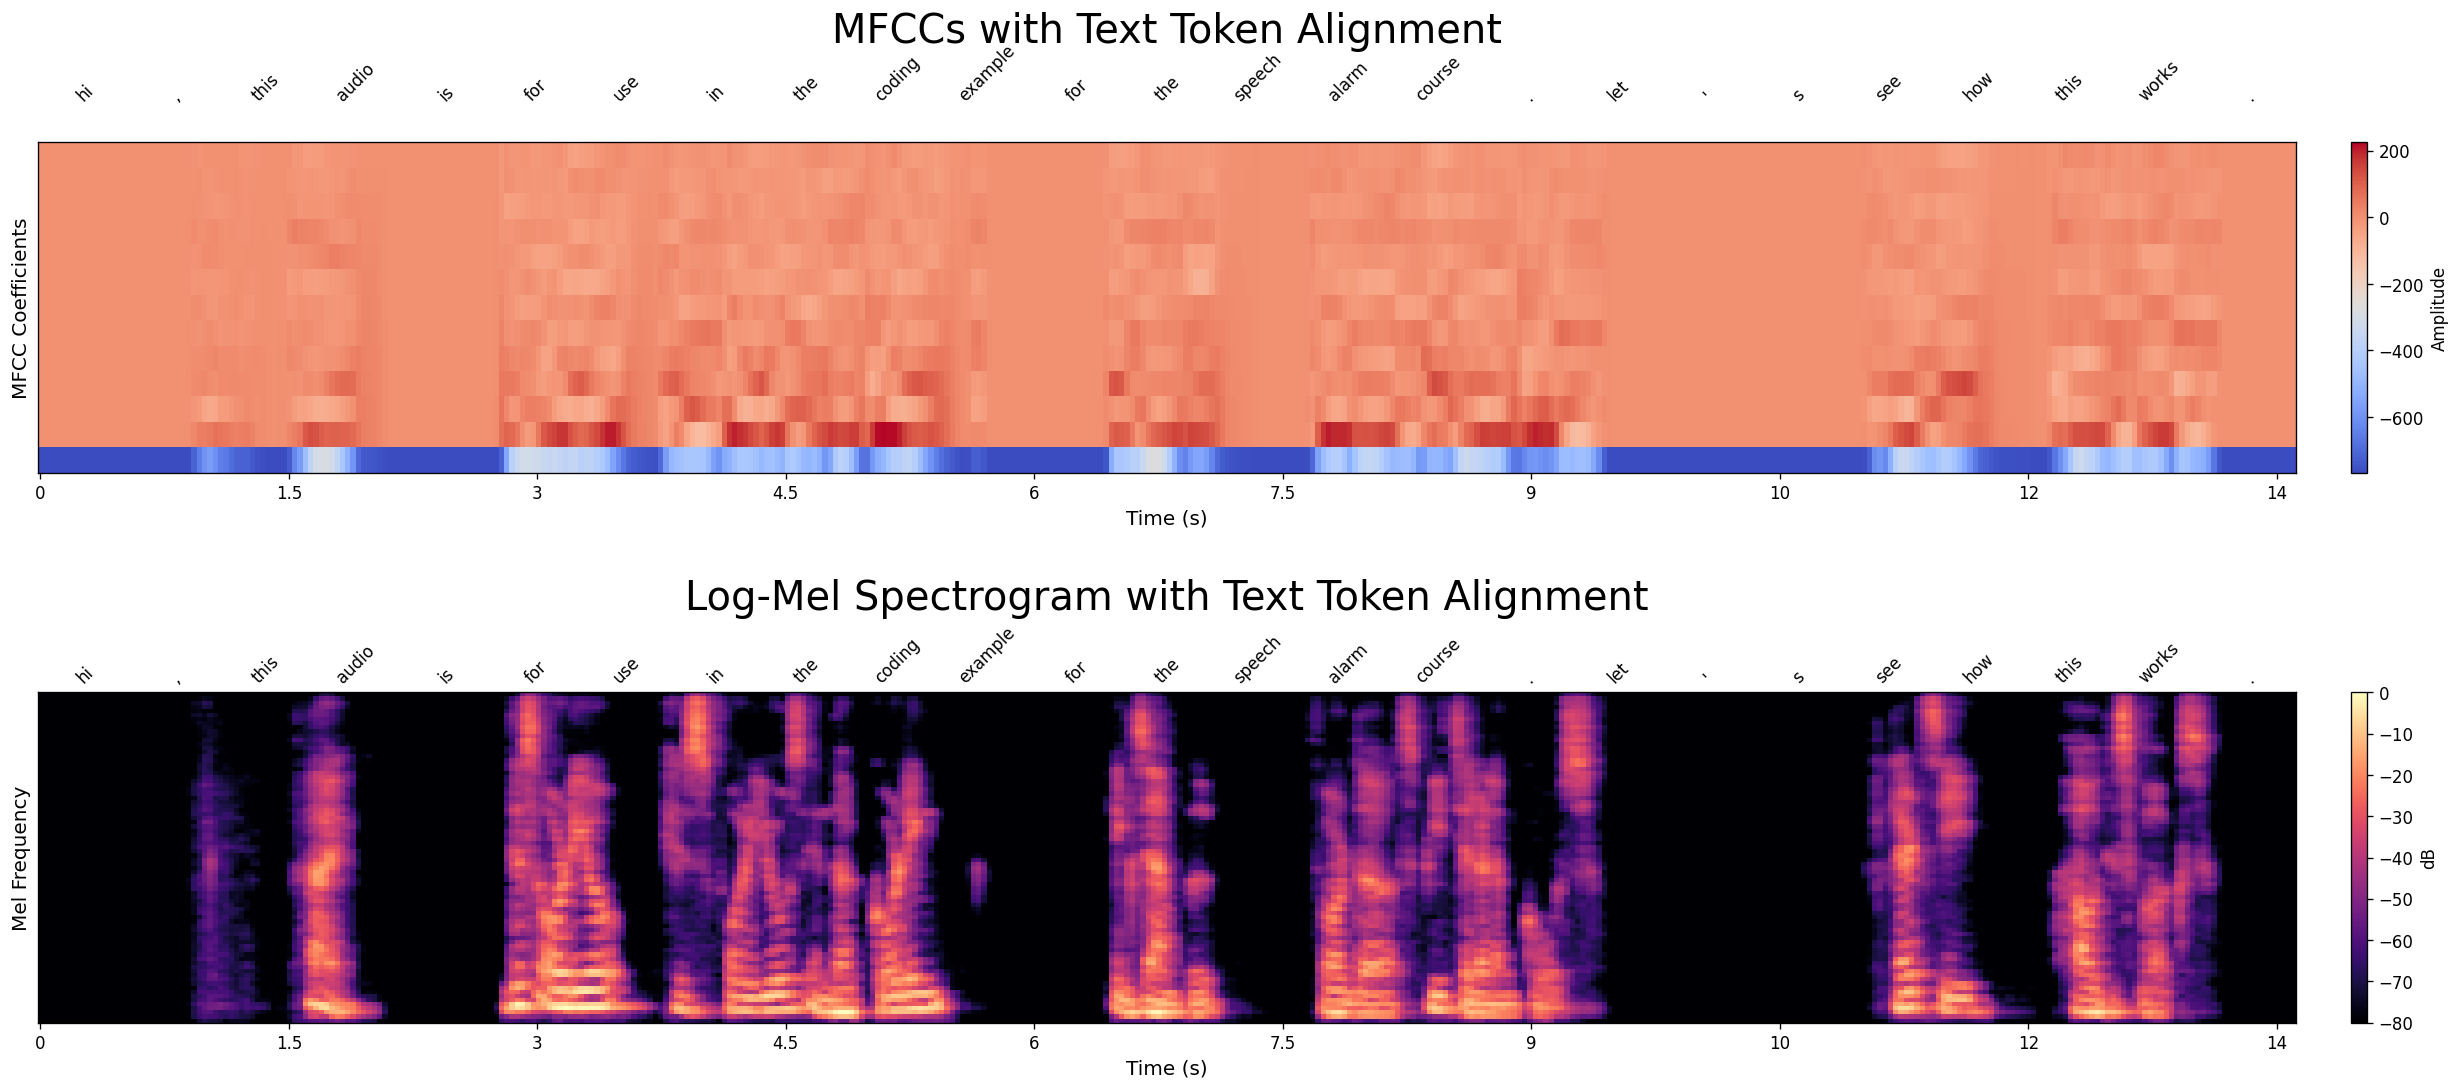

In [16]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import scipy.io.wavfile as wavfile
import whisper

# Parameters
sample_rate = 16000  # Hz
audio_duration = 3   # 3 is arbitrary value that's updated later  after loading audio. Its a placeholder value

# Function to load a real audio file
def load_audio():
    """Load a real audio file (input_audio.wav)."""
    audio, sr = librosa.load("input_audio.wav", sr=sample_rate)
    global audio_duration
    audio_duration = len(audio) / sample_rate
    return audio

# Function to extract audio features
def extract_audio_features(audio, sample_rate):
    """Extract MFCCs and log-mel spectrograms."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=80)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mfcc, mel_spec_db

# Function to extract text representations
def extract_text_representations(text):
    """Extract subword tokens using BERT tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    tokens = tokenizer.tokenize(text.lower())
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    return tokens, token_ids

# Function to simulate cross-modal alignment
def simulate_cross_modal_alignment(mfcc, tokens, audio_duration):
    """Align text tokens with MFCC frames."""
    num_frames = mfcc.shape[1]
    tokens_per_frame = len(tokens) / num_frames if num_frames > 0 else 0
    alignments = []
    for i, token in enumerate(tokens):
        time_point = (i + 0.5) * (audio_duration / len(tokens))
        frame_idx = int(i * num_frames / len(tokens))
        alignments.append((token, time_point, frame_idx))
    return alignments, tokens_per_frame

# Function to visualize cross-modal alignment
def visualize_cross_modal_alignment(mfcc, mel_spec, alignments, sample_rate, audio_duration):
    """Visualize MFCCs and mel spectrogram with aligned text tokens."""
    plt.figure(figsize=(24, 10), dpi=120)
    
    # Plot MFCCs
    plt.subplot(2, 1, 1)
    librosa.display.specshow(mfcc, x_axis='time', sr=sample_rate)
    plt.title("MFCCs with Text Token Alignment", fontsize=24, pad=60)
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("MFCC Coefficients", fontsize=12)
    plt.colorbar(label="Amplitude", pad=0.02)
    
    # Add token annotations
    for token, time_point, _ in alignments:
        plt.text(time_point, mfcc.shape[0] + 1, token, color='black', fontsize=10, ha='center', va='bottom', rotation=45)
    
    # Plot Mel Spectrogram
    plt.subplot(2, 1, 2)
    librosa.display.specshow(mel_spec, x_axis='time', sr=sample_rate)
    plt.title("Log-Mel Spectrogram with Text Token Alignment", fontsize=24, pad=50)
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Mel Frequency", fontsize=12)
    plt.colorbar(label="dB", pad=0.02)
    
    # Add token annotations
    for token, time_point, _ in alignments:
        plt.text(time_point, mel_spec.shape[0] + 1, token, color='black', fontsize=10, ha='center', va='bottom', rotation=45)
    
    #plt.tight_layout(pad=2.0)
    plt.tight_layout(pad=4.0, h_pad=3.0)
    plt.savefig("cross_modal_alignment.png", bbox_inches='tight', dpi=120)
    plt.show()

# Main function
def main():
    # Load audio from file
    audio = load_audio()
    
    # Use Whisper to transcribe the audio
    model = whisper.load_model("base")
    result = model.transcribe("input_audio.wav")
    text = result["text"]
    print(f"Whisper ASR Transcript: {text}")
    
    # Extract audio features
    mfcc, mel_spec = extract_audio_features(audio, sample_rate)
    
    # Extract text representations
    tokens, token_ids = extract_text_representations(text)
    print(f"Text Tokens: {tokens}")
    print(f"Token IDs: {token_ids}")
    
    # Simulate cross-modal alignment
    alignments, tokens_per_frame = simulate_cross_modal_alignment(mfcc, tokens, audio_duration)
    print(f"\nCross-Modal Alignment:")
    print(f"Tokens per Frame: {tokens_per_frame:.2f}")
    for token, time, frame in alignments:
        print(f"Token: {token}, Time: {time:.2f}s, Frame: {frame}")
    
    # Visualize alignment
    visualize_cross_modal_alignment(mfcc, mel_spec, alignments, sample_rate, audio_duration)

if __name__ == "__main__":
    main()

### Code Explaination:
The provided code demonstrates cross-modal alignment between audio and text by processing an audio file, transcribing it, extracting features, and visualizing the alignment. Here's a step-by-step explanation:
1. Libraries & Parameters

    Imports: Uses libraries for audio processing (librosa, scipy), machine learning (transformers, whisper), and visualization (matplotlib).

    Parameters: Sets sample_rate (16kHz) and initial audio_duration (3s placeholder).

2. Key Functions
load_audio()

    Loads input_audio.wav using librosa, updates audio_duration based on the actual audio length, and returns the audio data.

extract_audio_features(audio, sample_rate)

    MFCCs: Computes 13 Mel-frequency cepstral coefficients to capture spectral features.

    Mel Spectrogram: Generates an 80-band log-mel spectrogram (converted to dB) for time-frequency analysis.

extract_text_representations(text)

    Tokenizes the input text using BERT’s tokenizer (lowercase, subword tokens) and converts tokens to IDs.

simulate_cross_modal_alignment(...)

    Alignment Logic: Distributes text tokens uniformly across audio frames.

        Calculates tokens_per_frame (tokens/frame ratio).

        Assigns each token a time_point (evenly spaced over duration) and frame_idx (mapped to MFCC frames).

visualize_cross_modal_alignment(...)

    Plots MFCCs and mel spectrogram with text tokens annotated at aligned time points using matplotlib.

3. Main Workflow

    Load Audio: Reads input_audio.wav and updates its duration.

    Transcribe with Whisper: Uses Whisper ASR to convert audio to text.

    Extract Features:

        Audio: MFCCs and mel spectrogram.

        Text: Subword tokens and their IDs from the transcription.

    Simulate Alignment: Maps tokens to audio frames/time points.

    Visualize: Overlays tokens on MFCC and mel plots for cross-modal analysis.

4. Key Considerations

    Simplified Alignment: Tokens are evenly distributed, not accounting for actual speech dynamics (e.g., pauses).

    Use Cases: Demonstrates basic audio-text alignment for education/visualization; real-world systems use advanced models (e.g., CTC, attention).

    Output: Saves cross_modal_alignment.png showing tokens aligned to audio features.

Example Output

    Terminal: Prints Whisper transcript, tokens, token IDs, and alignment details.

    Plot: Two subplots with MFCCs and mel spectrogram, annotated with tokens at calculated time points.

This code provides a foundational approach to linking speech and text, useful for understanding multimodal ML concepts.